## Multirun Stability Analysis: Learning Rate, Dtype, and Normalization
This notebook analyzes runs created with `train_multirun.sbatch`-style naming.
It compares:
- learning rate (`probe_head_lr`) effects
- dtype/normalization variant effects (`ln_fp32` vs `fp32_only`)
- Apertus-trained vs Llama-trained probes on matching layers.

In [7]:
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import wandb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

api = wandb.Api()
ENTITY = "ethz-lsai-25"
PROJECT = "hallucination-probes"
RUN_PATH = f"{ENTITY}/{PROJECT}"

In [8]:
LAYERS = [10, 20, 26, 30]
SEEDS = [42, 43, 44]
LRS = ["3e-4", "1e-4", "3e-5"]
TEST_MODELS = ["apertus", "llama"]
METRIC_FAMILIES = ["all", "span", "span_max"]
METRICS = ["auc", "f1", "acc"]

LR_TAG_TO_VALUE = {"3em4": "3e-4", "1em4": "1e-4", "3em5": "3e-5"}
APERTUS_PATTERN = re.compile(
    r"^apertus_no_lora_(ln_fp32|fp32_only)_layer(10|20|26|30)_seed(42|43|44)_lr(3em4|1em4|3em5)$"
)
LAYERS_BASELINE_PATTERN = re.compile(
    r"^(apertus|llama)_no_lora_long_form_layer(10|20|26|30)_seed(42|43|44)$"
)


def _safe_float(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return None

In [9]:
rows = []
for run in api.runs(RUN_PATH):
    name = run.name or ""
    summary = run.summary._json_dict
    created_at = pd.to_datetime(run.created_at, utc=True)

    m_ap = APERTUS_PATTERN.match(name)
    if m_ap:
        variant, layer, seed, lr_tag = m_ap.groups()
        row = {
            "run_id": run.id,
            "run_name": name,
            "state": run.state,
            "created_at": created_at,
            "train_model": "apertus",
            "variant": variant,
            "layer": int(layer),
            "seed": int(seed),
            "lr": LR_TAG_TO_VALUE[lr_tag],
        }
    else:
        m_base = LAYERS_BASELINE_PATTERN.match(name)
        if not m_base:
            continue
        base_model, layer, seed = m_base.groups()
        row = {
            "run_id": run.id,
            "run_name": name,
            "state": run.state,
            "created_at": created_at,
            "train_model": base_model,
            "variant": f"{base_model}_layers",
            "layer": int(layer),
            "seed": int(seed),
            "lr": None,
        }

    for test_model in TEST_MODELS:
        for family in METRIC_FAMILIES:
            for metric in METRICS:
                k = f"train/longfact_test_{test_model}/{family}_{metric}"
                row[k] = _safe_float(summary.get(k))
    rows.append(row)

df_runs = pd.DataFrame(rows)
if df_runs.empty:
    raise ValueError("No matching runs found.")

state_rank = {"finished": 0, "running": 1, "queued": 2, "failed": 3, "crashed": 4}
df_runs["_state_rank"] = df_runs["state"].map(state_rank).fillna(99)
df_runs = (
    df_runs.sort_values(["_state_rank", "created_at"], ascending=[True, False])
    .drop_duplicates(["train_model", "variant", "layer", "seed", "lr"], keep="first")
    .drop(columns=["_state_rank"])
    .reset_index(drop=True)
)

print(df_runs.groupby(["train_model", "variant"]).size())
print("Note: '*_layers' baselines are sourced from layers.ipynb-style runs with lr=1e-3.")
df_runs.head()

train_model  variant       
apertus      apertus_layers    12
             fp32_only         36
             ln_fp32           36
llama        llama_layers      12
dtype: int64
Note: '*_layers' baselines are sourced from layers.ipynb-style runs with lr=1e-3.


,run_id,run_name,state,created_at,train_model,variant,layer,seed,lr,train/longfact_test_apertus/all_auc,...,train/longfact_test_apertus/span_max_acc,train/longfact_test_llama/all_auc,train/longfact_test_llama/all_f1,train/longfact_test_llama/all_acc,train/longfact_test_llama/span_auc,train/longfact_test_llama/span_f1,train/longfact_test_llama/span_acc,train/longfact_test_llama/span_max_auc,train/longfact_test_llama/span_max_f1,train/longfact_test_llama/span_max_acc
0,8ov1yhns,apertus_no_lora_fp32_only_layer26_seed42_lr3em5,finished,2026-03-09 20:58:34+00:00,apertus,fp32_only,26,42,3e-5,0.623001,...,None,0.648944,0.112951,None,0.657952,0.521169,None,0.649024,0.435554,None
1,yh7c764b,apertus_no_lora_fp32_only_layer26_seed43_lr3em4,finished,2026-03-09 20:58:30+00:00,apertus,fp32_only,26,43,3e-4,NaN,...,None,0.622589,0.106229,None,0.648922,0.528963,None,0.651761,0.450889,None
2,6j9rcsgm,apertus_no_lora_fp32_only_layer30_seed42_lr1em4,finished,2026-03-09 20:58:02+00:00,apertus,fp32_only,30,42,1e-4,0.648267,...,None,0.635054,0.103691,None,0.666473,0.543166,None,0.659995,0.451394,None
3,9wd2kios,apertus_no_lora_fp32_only_layer30_seed43_lr1em4,finished,2026-03-09 20:58:01+00:00,apertus,fp32_only,30,43,1e-4,0.605883,...,None,0.630133,0.103671,None,0.659967,0.524526,None,0.648154,0.432516,None
4,z07fbqw1,apertus_no_lora_fp32_only_layer30_seed44_lr3em5,finished,2026-03-09 20:58:01+00:00,apertus,fp32_only,30,44,3e-5,0.628235,...,None,0.630506,0.104767,None,0.651151,0.534847,None,0.640351,0.434419,None


In [10]:
metric_columns = [
    f"train/longfact_test_{tm}/{fam}_{m}"
    for tm in TEST_MODELS
    for fam in METRIC_FAMILIES
    for m in METRICS
]

df_long = df_runs.melt(
    id_vars=["run_id", "run_name", "state", "created_at", "train_model", "variant", "layer", "seed", "lr"],
    value_vars=metric_columns,
    var_name="metric_key",
    value_name="value",
)

parsed = df_long["metric_key"].str.extract(
    r"train/longfact_test_(apertus|llama)/(all|span|span_max)_(auc|f1|acc)"
)
parsed.columns = ["test_model", "metric_family", "metric"]
df_long = pd.concat([df_long, parsed], axis=1).dropna(subset=["value", "test_model", "metric_family", "metric"])
df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")
df_long = df_long.dropna(subset=["value"]).reset_index(drop=True)

df_long["lr"] = pd.Categorical(df_long["lr"], categories=LRS, ordered=True)
df_long.head()

,run_id,run_name,state,created_at,train_model,variant,layer,seed,lr,metric_key,value,test_model,metric_family,metric
0,8ov1yhns,apertus_no_lora_fp32_only_layer26_seed42_lr3em5,finished,2026-03-09 20:58:34+00:00,apertus,fp32_only,26,42,3e-5,train/longfact_test_apertus/all_auc,0.623001,apertus,all,auc
1,6j9rcsgm,apertus_no_lora_fp32_only_layer30_seed42_lr1em4,finished,2026-03-09 20:58:02+00:00,apertus,fp32_only,30,42,1e-4,train/longfact_test_apertus/all_auc,0.648267,apertus,all,auc
2,9wd2kios,apertus_no_lora_fp32_only_layer30_seed43_lr1em4,finished,2026-03-09 20:58:01+00:00,apertus,fp32_only,30,43,1e-4,train/longfact_test_apertus/all_auc,0.605883,apertus,all,auc
3,z07fbqw1,apertus_no_lora_fp32_only_layer30_seed44_lr3em5,finished,2026-03-09 20:58:01+00:00,apertus,fp32_only,30,44,3e-5,train/longfact_test_apertus/all_auc,0.628235,apertus,all,auc
4,pipyfig3,apertus_no_lora_ln_fp32_layer20_seed43_lr1em4,finished,2026-03-09 20:58:00+00:00,apertus,ln_fp32,20,43,1e-4,train/longfact_test_apertus/all_auc,0.733313,apertus,all,auc


/tmp/ipykernel_993607/3815641268.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ap.groupby(["layer", "lr", "series"])


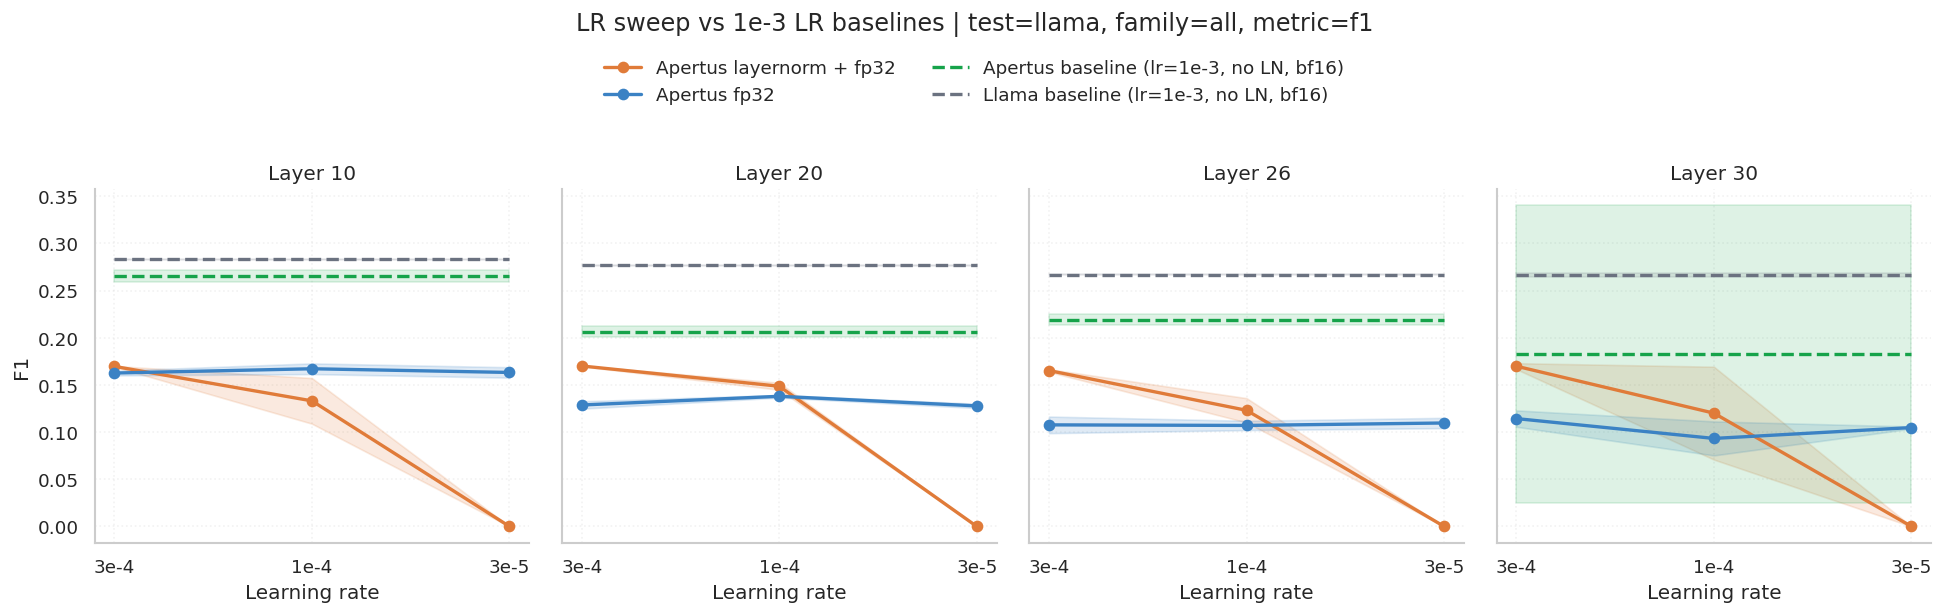

In [18]:
COLORS = {
    "apertus_fp32": "#3B82C4",
    "apertus_ln_fp32": "#E07B39",
    "apertus_layers": "#16A34A",
    "llama_layers": "#6B7280",
}


def plot_lr_three_way(df, metric_family="all", metric="auc", test_model="apertus"):
    sub = df[
        (df["metric_family"] == metric_family)
        & (df["metric"] == metric)
        & (df["test_model"] == test_model)
    ].copy()
    if sub.empty:
        raise ValueError("No rows for selected filters.")

    ap = sub[sub["variant"].isin(["fp32_only", "ln_fp32"])].copy()
    baselines = sub[sub["variant"].isin(["apertus_layers", "llama_layers"])].copy()

    ap["series"] = ap["variant"].map({"fp32_only": "apertus_fp32", "ln_fp32": "apertus_ln_fp32"})
    ap_agg = (
        ap.groupby(["layer", "lr", "series"])
        .agg(mean=("value", "mean"), std=("value", "std"))
        .reset_index()
    )
    ap_agg["std"] = ap_agg["std"].fillna(0.0)

    base_agg = (
        baselines.groupby(["layer", "variant"])
        .agg(mean=("value", "mean"), std=("value", "std"))
        .reset_index()
    )
    base_agg["std"] = base_agg["std"].fillna(0.0)

    xpos = list(range(len(LRS)))
    fig, axes = plt.subplots(1, len(LAYERS), figsize=(4.1 * len(LAYERS), 4.4), sharey=True)
    if len(LAYERS) == 1:
        axes = [axes]

    for ax, layer in zip(axes, LAYERS):
        d = ap_agg[ap_agg["layer"] == layer]
        for series in ["apertus_ln_fp32", "apertus_fp32"]:
            s = d[d["series"] == series].set_index("lr").reindex(LRS).reset_index()
            y = s["mean"].to_numpy()
            e = s["std"].to_numpy()
            if pd.isna(y).all():
                continue
            ax.plot(xpos, y, marker="o", linewidth=2, color=COLORS[series], label=series)
            ax.fill_between(xpos, y - e, y + e, color=COLORS[series], alpha=0.16)

        b = base_agg[base_agg["layer"] == layer]
        for base_variant in ["apertus_layers", "llama_layers"]:
            s = b[b["variant"] == base_variant]
            if s.empty:
                continue
            y0 = float(s["mean"].iloc[0])
            e0 = float(s["std"].iloc[0])
            ax.plot(xpos, [y0] * len(LRS), linestyle="--", linewidth=2, color=COLORS[base_variant], label=base_variant)
            ax.fill_between(xpos, [y0 - e0] * len(LRS), [y0 + e0] * len(LRS), color=COLORS[base_variant], alpha=0.14)

        ax.set_title(f"Layer {layer}")
        ax.set_xlabel("Learning rate")
        ax.set_xticks(xpos)
        ax.set_xticklabels(LRS)
        ax.grid(True, alpha=0.25, linestyle=":")
        ax.spines[["top", "right"]].set_visible(False)

    axes[0].set_ylabel(metric.upper())
    handles, labels = axes[0].get_legend_handles_labels()
    label_map = {
        "apertus_ln_fp32": "Apertus layernorm + fp32",
        "apertus_fp32": "Apertus fp32",
        "apertus_layers": "Apertus baseline (lr=1e-3, no LN, bf16)",
        "llama_layers": "Llama baseline (lr=1e-3, no LN, bf16)",
    }
    labels = [label_map.get(x, x) for x in labels]
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.10))
    fig.suptitle(f"LR sweep vs 1e-3 LR baselines | test={test_model}, family={metric_family}, metric={metric}", y=1.16)
    fig.tight_layout()
    plt.show()


plot_lr_three_way(df_long, metric_family="all", metric="f1", test_model="llama")